# Experiment: Benchmark All Tools

What this notebook teaches:
- Run the repository benchmark script from Colab or local runtime.
- Generate `benchmark.csv`, `benchmark.md`, and `environment.json` artifacts.
- Compare measured tools and keep unmeasured tools explicitly marked.


In [1]:
from __future__ import annotations

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/sumeyye-agac/human-pose-estimation-experiments.git"
REPO_NAME = "human-pose-estimation-experiments"
COLAB_REPO_DIR = Path("/content") / REPO_NAME

if "google.colab" in sys.modules:
    if not COLAB_REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(COLAB_REPO_DIR)], check=True)
    os.chdir(COLAB_REPO_DIR)

repo_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError("Could not locate repository root containing src/.")

os.chdir(repo_root)
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

print(f"Using repo root: {repo_root}")


Using repo root: /Users/sumeyyeagac/Desktop/GitHub_Sumeyye/human-pose-estimation-experiments


In [2]:
def pip_install(*packages: str) -> None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade-strategy", "only-if-needed", *packages], check=True)

pip_install("numpy<2", "pandas>=2.1,<2.3", "matplotlib>=3.8,<3.9")


In [3]:
import subprocess

subprocess.run(
    [
        sys.executable,
        "scripts/run_benchmarks.py",
        "--tool",
        "all",
        "--frames",
        "60",
        "--warmup",
        "12",
        "--repeat",
        "1",
    ],
    check=True,
)


I0000 00:00:1772748745.247502 12727646 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 88), renderer: Apple M3 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1772748745.312031 12727715 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1772748745.316329 12727724 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


/Users/sumeyyeagac/anaconda3/envs/posebench-d2/lib/python3.10/site-packages/detectron2/model_zoo/model_zoo.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
An exception occurred in telemetry logging.Disabling telemetry to prevent further exceptions.
Traceback (most recent call last):
  File "/Users/sumeyyeagac/anaconda3/envs/posebench-d2/lib/python3.10/site-packages/iopath/common/file_io.py", line 946, in __log_tmetry_keys
    handler.log_event()
  File "/Users/sumeyyeagac/anaconda3/envs/posebench-d2/lib/python3.10/site-packages/iopath/common/event_logger.py", line 97, in log_event
    del self._evt
AttributeError: _evt


An exception occurred in telemetry logging.Disabling telemetry to prevent further exceptions.
Traceback (most recent call last):
  File "/Users/sumeyyeagac/anaconda3/envs/posebench-d2/lib/python3.10/site-packages/iopath/common/file_io.py", line 946, in __log_tmetry_keys
    handler.log_event()
  File "/Users/sumeyyeagac/anaconda3/envs/posebench-d2/lib/python3.10/site-packages/iopath/common/event_logger.py", line 97, in log_event
    del self._evt
AttributeError: _evt


/Users/sumeyyeagac/anaconda3/envs/posebench-d2/lib/python3.10/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1770196967836/work/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Wrote results/benchmark.csv
Wrote results/benchmark.md
Wrote results/environment.json
Measured tools: mediapipe, detectron2, openpose


CompletedProcess(args=['/Users/sumeyyeagac/anaconda3/envs/posebench-d2/bin/python', 'scripts/run_benchmarks.py', '--tool', 'all', '--frames', '60', '--warmup', '12', '--repeat', '1'], returncode=0)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

benchmark_df = pd.read_csv(repo_root / "results" / "benchmark.csv")
benchmark_df


,tool,status,avg_ms_per_frame,std_ms_per_frame,fps,measured_frames,warmup_frames,repeat,include_decode,notes,raw_json
0,mediapipe,measured,7.582635,0.070468,131.880269,60,12,1,False,Synthetic single-frame benchmark. Inference only.,results/benchmark_raw_mediapipe.json
1,detectron2,measured,1032.951419,44.014467,0.968100,60,12,1,False,Synthetic single-frame benchmark. Inference only.,results/benchmark_raw_detectron2.json
2,openpose,measured,428.362319,8.360000,2.334472,60,12,1,False,Synthetic single-frame benchmark. Inference on...,results/benchmark_raw_openpose.json
3,alphapose,not_measured,NaN,NaN,NaN,60,12,1,False,AlphaPose official install requires CUDA custo...,NaN


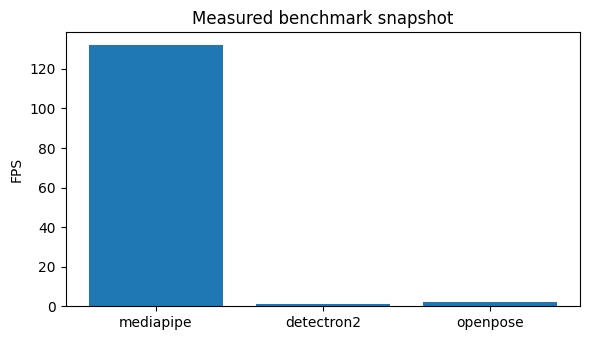

Saved /Users/sumeyyeagac/Desktop/GitHub_Sumeyye/human-pose-estimation-experiments/assets/generated/benchmark_fps.png


In [5]:
measured = benchmark_df[benchmark_df["status"] == "measured"].copy()

if measured.empty:
    print("No measured rows yet. Run tool-specific setup notebooks first.")
else:
    plt.figure(figsize=(6, 3.5))
    plt.bar(measured["tool"], measured["fps"])
    plt.ylabel("FPS")
    plt.title("Measured benchmark snapshot")
    plt.tight_layout()
    figure_path = repo_root / "assets" / "generated" / "benchmark_fps.png"
    figure_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(figure_path, dpi=140)
    plt.show()
    print("Saved", figure_path)
